In [141]:
import pandas as pd

# import data from csv-file
df = pd.read_csv("../streamlit/sthlm_puls/src/sthlm_puls/assets/data/events_combined.csv")

df

,event_id,name,url,image_url,date,time,status,segment,genre,subgenre,...,venue_city,venue_address,venue_lat,venue_lon,day_of_week,month_name,month_num,year,hour,source
0,846ff6e2-f120-44cc-bfbd-1ddada64932e,Through the Playful Eyes of Elliott Erwitt,https://stockholm.fotografiska.com/,https://images.unsplash.com/...,2026-04-19,NaN,onsale,Arts & Theatre,Culture & Arts,Nature & Society,...,Stockholm,Stadsgårdshamnen 22,59.317995,18.084650,Sunday,April,4,2026,NaN,visitstockholm
1,754fbad2-0b00-44a7-8a7a-cc5b7e725747,Frankenstein – Kulturhuset Stadsteatern,https://kulturhusetstadsteatern.se/teater/fran...,https://images.unsplash.com/...,2026-04-19,NaN,onsale,Arts & Theatre,Film,Stand-up & Spoken Word,...,Stockholm,Sergels Torg,59.332034,18.064931,Sunday,April,4,2026,NaN,visitstockholm
2,5cd53c5d-1e59-46e7-94aa-710d324e8550,Festive Table Settings!,https://gustavsbergsporslinsmuseum.se/att-se-g...,https://images.unsplash.com/...,2026-04-19,NaN,onsale,Arts & Theatre,Culture & Arts,Nature & Society,...,Gustavsberg,Odelbergs väg 5,59.324357,18.383381,Sunday,April,4,2026,NaN,visitstockholm
3,bdf1e0b9-2ff7-4dc1-b5f1-a53683a6dbe5,I am Me! Minorities in Sweden.,https://www.levandehistoria.se/utstallning/uts...,https://images.unsplash.com/...,2026-04-19,NaN,onsale,Arts & Theatre,Culture & Arts,Nature & Society,...,Stockholm,Stora Nygatan 10,59.324947,18.067927,Sunday,April,4,2026,NaN,visitstockholm
4,6d8cd112-dd4d-40c0-884d-36ea06cda595,"Stockholm Archipelago Winter Kayaking, Hot Sau...",https://kanotcenter.com/tours/winter-kayak-tou...,https://images.unsplash.com/...,2026-04-19,NaN,onsale,Arts & Theatre,NaN,NaN,...,Vaxholm,Resarövägen 10,59.417420,18.314396,Sunday,April,4,2026,NaN,visitstockholm
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
654,NaN,ULD,https://www.fasching.se/uld-2026-12-06/#2026-1...,https://www.fasching.se/wp-content/uploads/202...,2026-12-06,20:00,onsale,Nightlife,Jazz/Klubb,NaN,...,Stockholm,"Kungsgatan 63, Stockholm",59.333400,18.055700,Sunday,December,12,2026,20.0,fasching
655,NaN,NUET x INNELLEA,https://berns.se/calendar/nuet-x-innellea/,https://berns.se/wp-content/uploads/2026/03/IN...,2026-04-24,NaN,onsale,Nightlife,Klubb/Konsert,NaN,...,Stockholm,"Berzelii Park, Stockholm",59.332300,18.073400,Friday,April,4,2026,NaN,berns
656,NaN,Eric Gadd x Blacknuss,https://berns.se/calendar/eric-gadd-x-blacknuss/,https://berns.se/wp-content/uploads/2026/02/ga...,2026-04-25,NaN,onsale,Nightlife,Klubb/Konsert,NaN,...,Stockholm,"Berzelii Park, Stockholm",59.332300,18.073400,Saturday,April,4,2026,NaN,berns
657,NaN,BULLERBYN x VALBORG,https://berns.se/calendar/bullerbyn-x-valborg-2/,https://berns.se/wp-content/uploads/2026/03/BB...,2026-04-30,NaN,onsale,Nightlife,Klubb/Konsert,NaN,...,Stockholm,"Berzelii Park, Stockholm",59.332300,18.073400,Thursday,April,4,2026,NaN,berns


In [142]:
# Count the number of events per genre
df['genre'].value_counts()

genre
Jazz & Blues             230
Jazz/Klubb                87
Culture & Arts            64
Film                      49
Games & Championships     22
Conventions & Fairs       12
Klubb/Konsert              4
Name: count, dtype: int64

In [143]:
df['source'].value_counts()

source
visitstockholm    568
fasching           87
berns               4
Name: count, dtype: int64

In [144]:
# Find the top 3 dates with the highest number of events
df['date'].value_counts().nlargest(3)

date
2026-04-19    56
2026-04-25    39
2026-05-09    22
Name: count, dtype: int64

In [145]:
# Display top 10 most common venues
df['venue_name'].value_counts().nlargest(10)

venue_name
Fasching                          88
Debaser Nova                      41
Debaser Strand                    34
Avicii Arena                      20
Kollektivet Livet Bar och Scen    14
Fållan                            12
Gamla stan                        11
Södra Teatern                      9
Nationalmuseum                     8
Nalen                              8
Name: count, dtype: int64

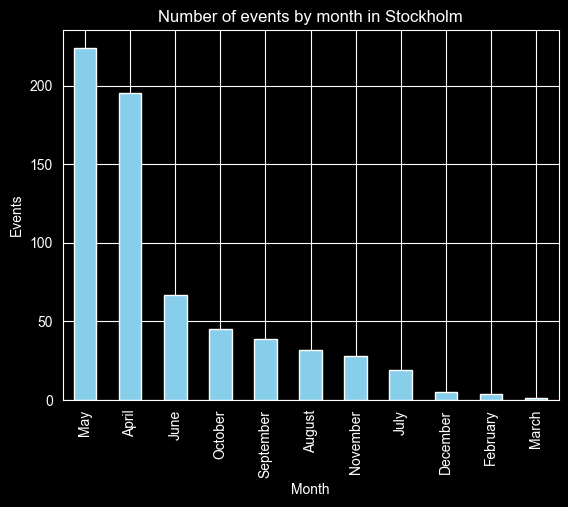

In [146]:
import matplotlib.pyplot as plt

# Count and visualize events per month using a bar chart
month_counts = df['month_name'].value_counts()

month_counts.plot(kind='bar', color='skyblue', edgecolor='white')

plt.title('Number of events by month in Stockholm')
plt.xlabel('Month')
plt.ylabel('Events')

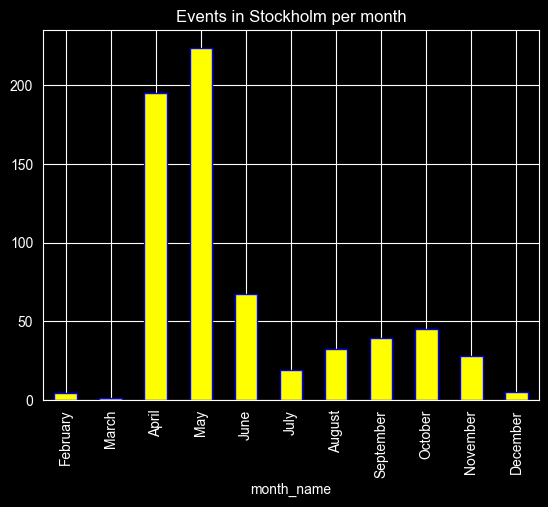

In [147]:
# Visualize events per month in chronological order
month_order = ['January', 'February', 'March', 'April', 'May', 'June',
               'July', 'August', 'September', 'October', 'November', 'December']

counts = df['month_name'].value_counts()

counts_sorted = counts.reindex(month_order).dropna()

counts_sorted.plot(kind='bar', color='yellow', edgecolor='blue')
plt.title("Events in Stockholm per month")

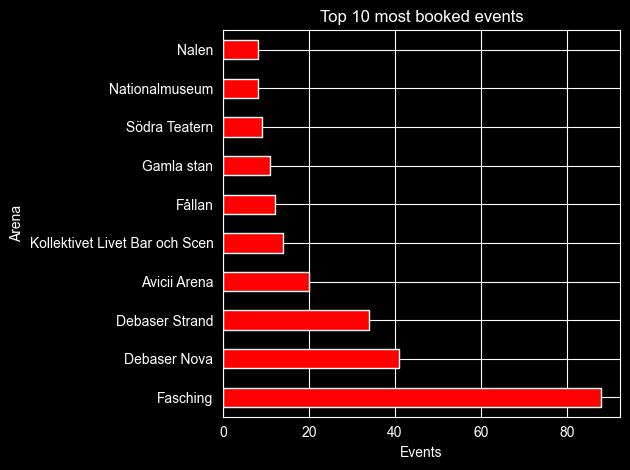

In [148]:
# Visualize the top 10 venues with the most events
venue_counts = df['venue_name'].value_counts()

top_10_venues = venue_counts.head(10)

top_10_venues.plot(kind='barh', color='red')

plt.title("Top 10 most booked events")
plt.xlabel("Events")
plt.ylabel('Arena')
plt.tight_layout()

In [149]:
import duckdb
# Query to count events by day of the week
duckdb.sql("""
SELECT day_of_week, COUNT(*) AS num_events
FROM df
GROUP BY day_of_week
ORDER BY num_events DESC
""")

┌─────────────┬────────────┐
│ day_of_week │ num_events │
│   varchar   │   int64    │
├─────────────┼────────────┤
│ Saturday    │        162 │
│ Sunday      │        131 │
│ Friday      │        107 │
│ Thursday    │         87 │
│ Wednesday   │         74 │
│ Tuesday     │         52 │
│ Monday      │         46 │
└─────────────┴────────────┘

In [150]:
# Find the top 5 venues with the most unique set of genres
duckdb.sql("""
SELECT venue_name, COUNT(DISTINCT genre) AS unique_genres
FROM df
WHERE venue_name IS NOT NULL
GROUP BY venue_name
ORDER BY unique_genres DESC
LIMIT 5
""")

┌──────────────────────────────┬───────────────┐
│          venue_name          │ unique_genres │
│           varchar            │     int64     │
├──────────────────────────────┼───────────────┤
│ Kulturhuset Stadsteatern     │             3 │
│ Scalateatern                 │             2 │
│ Folkoperan                   │             2 │
│ Solvalla                     │             2 │
│ Filadelfia Convention Center │             2 │
└──────────────────────────────┴───────────────┘

In [151]:
# Count events grouped by month and segment
duckdb.sql("""
SELECT month_name, segment, COUNT(*) AS num_events
FROM df
GROUP BY month_name, segment
ORDER BY month_name, num_events DESC
""")

┌────────────┬────────────────┬────────────┐
│ month_name │    segment     │ num_events │
│  varchar   │    varchar     │   int64    │
├────────────┼────────────────┼────────────┤
│ April      │ Arts & Theatre │         96 │
│ April      │ Music          │         45 │
│ April      │ Miscellaneous  │         39 │
│ April      │ Nightlife      │         12 │
│ April      │ Sports         │          3 │
│ August     │ Music          │         15 │
│ August     │ Nightlife      │          8 │
│ August     │ Sports         │          5 │
│ August     │ Arts & Theatre │          3 │
│ August     │ Miscellaneous  │          1 │
│   ·        │       ·        │          · │
│   ·        │       ·        │          · │
│   ·        │       ·        │          · │
│ November   │ Miscellaneous  │          1 │
│ October    │ Music          │         26 │
│ October    │ Nightlife      │         15 │
│ October    │ Arts & Theatre │          3 │
│ October    │ Miscellaneous  │          1 │
│ Septembe

In [152]:
# Show events as 'Day' or 'Evening' based on the hour
duckdb.sql("""
SELECT
    CASE WHEN hour >= 18 THEN 'Evening' ELSE 'Day' END AS time_of_day,
    COUNT(*) AS num_events
FROM df
WHERE hour IS NOT NULL
GROUP BY time_of_day
""")

┌─────────────┬────────────┐
│ time_of_day │ num_events │
│   varchar   │   int64    │
├─────────────┼────────────┤
│ Day         │          2 │
│ Evening     │         85 │
└─────────────┴────────────┘

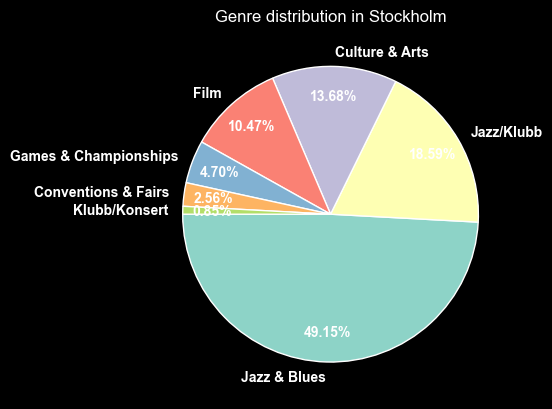

In [153]:
# Pie chart showing top 10 genre distribution
df['genre'].value_counts().head(10).plot(
    kind='pie',
    autopct='%2.2f%%',
    startangle=180,
    pctdistance=0.80,
    textprops={'color': 'white', 'weight': 'bold', 'fontsize': 10}
)

plt.title('Genre distribution in Stockholm', color='white')
plt.ylabel('')

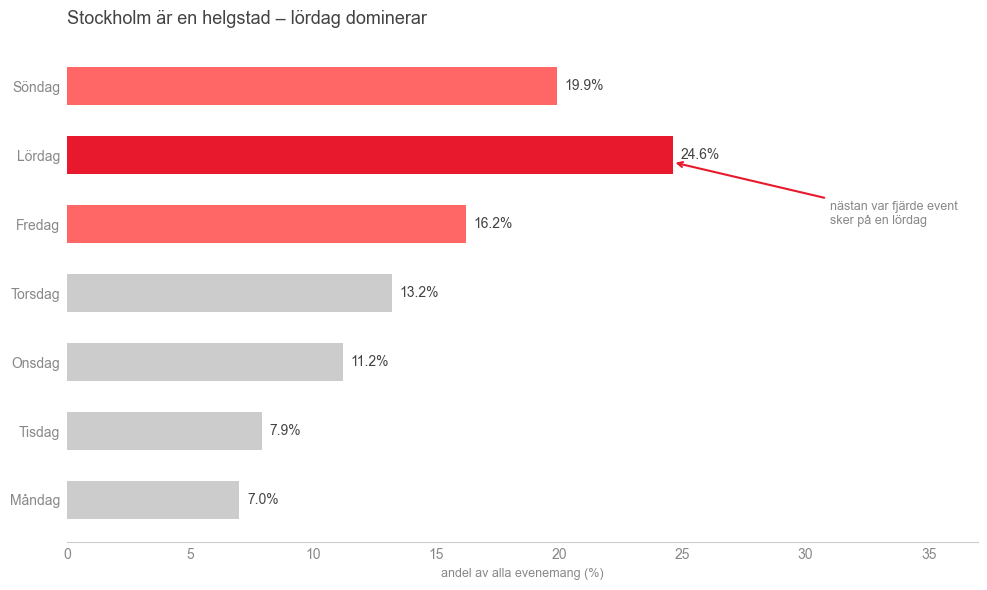

In [11]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv('../streamlit/sthlm_puls/src/sthlm_puls/assets/data/events_combined.csv')

BAKGRUND  = '#FFFFFF'
KORALL    = '#FF6666'
HIGHLIGHT = '#E8192C'
GRAY_1    = '#CCCCCC'
GRAY_2    = '#888888'
GRAY_3    = '#444444'
NORMAL    = '#CCCCCC'

# Måndag överst i listan = måndag nederst i barh, söndag överst
day_order  = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
day_labels = ['Måndag', 'Tisdag', 'Onsdag', 'Torsdag', 'Fredag', 'Lördag', 'Söndag']

day_counts = df['day_of_week'].value_counts().reindex(day_order).fillna(0)
total = day_counts.sum()
pct = (day_counts / total * 100).round(1)

colors = []
for day in day_order:
    if day == 'Saturday':
        colors.append(HIGHLIGHT)
    elif day in ['Friday', 'Sunday']:
        colors.append(KORALL)
    else:
        colors.append(NORMAL)

fig, ax = plt.subplots(figsize=(10, 6))
fig.patch.set_facecolor(BAKGRUND)
ax.set_facecolor(BAKGRUND)

bars = ax.barh(day_labels, pct.values, color=colors, height=0.55, edgecolor='none')

for bar, val in zip(bars, pct.values):
    ax.text(bar.get_width() + 0.3, bar.get_y() + bar.get_height()/2,
            f'{val}%', va='center', ha='left', color=GRAY_3, fontsize=10)

ax.spines[['top', 'right', 'left']].set_visible(False)
ax.spines['bottom'].set_color(GRAY_1)
ax.tick_params(colors=GRAY_2, labelsize=10, length=0, pad=5)
ax.set_xlabel('andel av alla evenemang (%)', color=GRAY_2, fontsize=9)
ax.set_ylabel('')
ax.set_xlim(0, 37)

ax.set_title(
    'Stockholm är en helgstad – lördag dominerar',
    loc='left',
    color=GRAY_3,
    fontsize=13,
    pad=15
)

# Lördag är index 5 i day_labels (y-position = 5)
ax.annotate(
    text='nästan var fjärde event\nsker på en lördag',
    xy=(pct['Saturday'], 4.9),
    xytext=(31, 4.0),
    color=GRAY_2,
    fontsize=9,
    arrowprops=dict(arrowstyle='->', color=HIGHLIGHT, lw=1.5)
)

fig.tight_layout()
fig.savefig('data_images/storytelling_weekend-activity.png', dpi=250, bbox_inches='tight', facecolor=BAKGRUND)

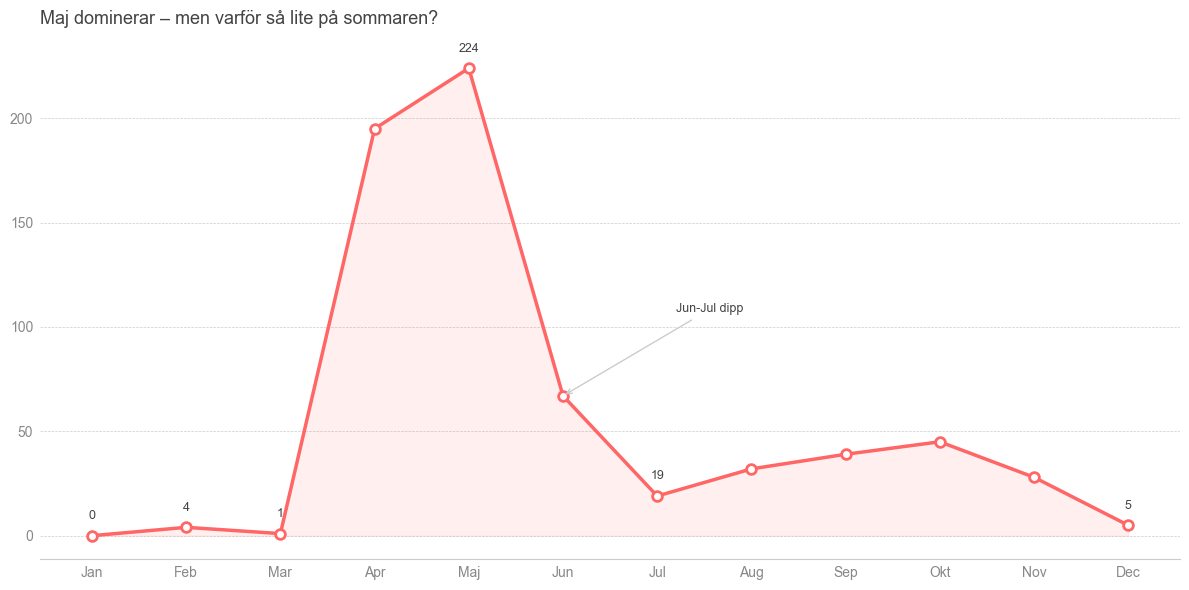

In [158]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv('../streamlit/sthlm_puls/src/sthlm_puls/assets/data/events_combined.csv')

BAKGRUND = '#FFFFFF'
KORALL = '#FF6666'
GRAY_1 = '#CCCCCC'
GRAY_2 = '#888888'
GRAY_3 = '#444444'

month_order = list(range(1, 13))
month_labels = ['Jan', 'Feb', 'Mar', 'Apr', 'Maj', 'Jun', 'Jul', 'Aug', 'Sep', 'Okt', 'Nov', 'Dec']

month_counts = df.groupby('month_num').size().reindex(month_order).fillna(0)

fig, ax = plt.subplots(figsize=(12, 6))
fig.patch.set_facecolor(BAKGRUND)
ax.set_facecolor(BAKGRUND)

ax.plot(month_labels, month_counts.values, color=KORALL, linewidth=2.5,
        marker='o', markersize=7, markerfacecolor='white',
        markeredgecolor=KORALL, markeredgewidth=2)
ax.fill_between(month_labels, month_counts.values, alpha=0.1, color=KORALL)

for i, val in enumerate(month_counts.values):
    if val > 200 or val < 20:
        ax.text(i, val + 8, str(int(val)), ha='center', color=GRAY_3, fontsize=9)

ax.spines[['top', 'right', 'left']].set_visible(False)
ax.spines['bottom'].set_color(GRAY_1)
ax.tick_params(colors=GRAY_2, labelsize=10, length=0, pad=5)
ax.yaxis.grid(True, color=GRAY_1, linewidth=0.5, linestyle='--')
ax.set_axisbelow(True)

ax.set_title(
    'Maj dominerar – men varför så lite på sommaren?',
    loc='left',
    color=GRAY_3,
    fontsize=13,
    pad=15
)

# sommardipp verkar konstigt låg
ax.annotate(
    xy=(5, month_counts.values[5]),
    text='Jun-Jul dipp',
    color=GRAY_3,
    fontsize=9,
    xytext=(6.2, month_counts.values[5] + 40),
    arrowprops=dict(arrowstyle='->', color=GRAY_1, lw=1)
)

fig.tight_layout()
fig.savefig('data_images/storytelling_seasonal.png', dpi=250, bbox_inches='tight', facecolor=BAKGRUND)